In [1]:
# ============================================================
# PROJECT UAS
# Prediksi Harga Mobil Bekas Menggunakan Machine Learning
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("cardekho.csv")

print("="*60)
print("DATASET CARDEKHO")
print("="*60)

print(df.head())

DATASET CARDEKHO
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    

In [3]:
df = pd.read_csv("cardekho.csv")

print(df.head())
print(df.info())

                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5.0  
4      88.2

In [4]:
# ============================================================
# Eksplorasi Dataset
# ============================================================

print("\nInformasi Dataset")
print(df.info())

print("\nStatistik Deskriptif")
print(df.describe())

print("\nUkuran Dataset")
print(df.shape)

print("\nMissing Value")
print(df.isnull().sum())


Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB
None

Statistik Deskriptif
              year  selling_price     km_driven  mileage(km/ltr/kg)  \
count  8128.000000   8.128

# **CELL 4**
Pada tahap ini dilakukan proses pembersihan data (Data Cleaning). Proses meliputi pengecekan nilai kosong (missing value), penghapusan data yang memiliki nilai kosong, serta penghapusan data duplikat. Tahapan ini bertujuan agar data yang digunakan dalam proses pelatihan model memiliki kualitas yang baik sehingga dapat meningkatkan performa model prediksi.

In [5]:
# ============================================================
# CELL 4 : Data Cleaning
# ============================================================

print("="*60)
print("DATA CLEANING")
print("="*60)

# Mengecek missing value
print("\nMissing Value Sebelum Cleaning")
print(df.isnull().sum())

# Menghapus missing value
df = df.dropna()

# Menghapus data duplikat
df = df.drop_duplicates()

print("\nMissing Value Setelah Cleaning")
print(df.isnull().sum())

print("\nUkuran Dataset Setelah Cleaning")
print(df.shape)

DATA CLEANING

Missing Value Sebelum Cleaning
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

Missing Value Setelah Cleaning
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

Ukuran Dataset Setelah Cleaning
(6718, 12)


# **CELL 5**
Tahap visualisasi data dilakukan untuk memahami karakteristik dataset. Visualisasi distribusi harga jual menunjukkan persebaran nilai target, sedangkan visualisasi tahun produksi dan jenis bahan bakar memberikan gambaran mengenai karakteristik mobil yang terdapat dalam dataset.

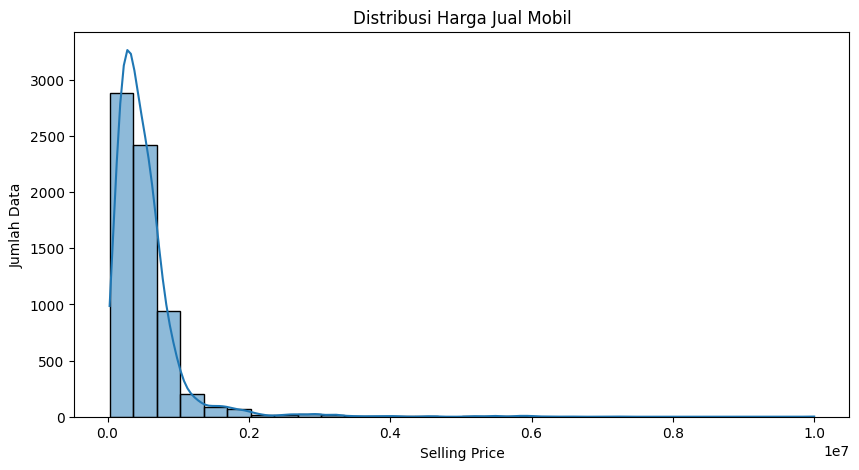

In [6]:
# ============================================================
# CELL 5 : Visualisasi Data
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title("Distribusi Harga Jual Mobil")

plt.xlabel("Selling Price")

plt.ylabel("Jumlah Data")

plt.show()

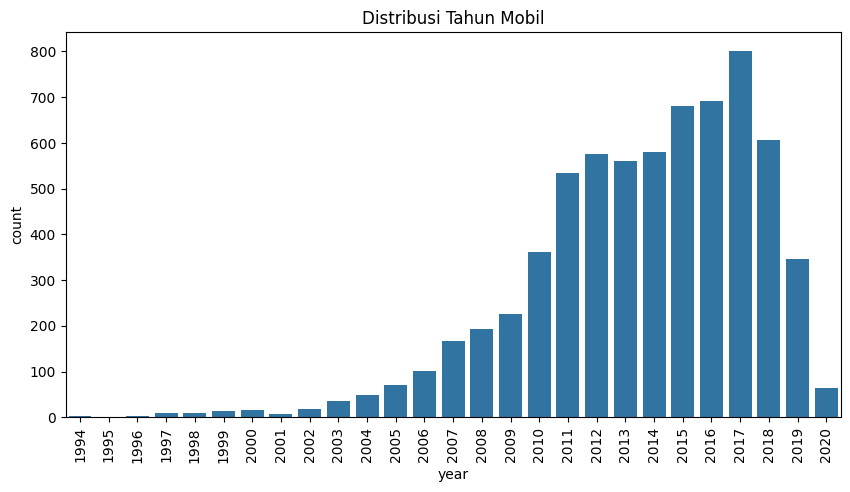

In [7]:
# ============================================================
# Visualisasi Tahun Mobil
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(data=df, x='year')

plt.xticks(rotation=90)

plt.title("Distribusi Tahun Mobil")

plt.show()

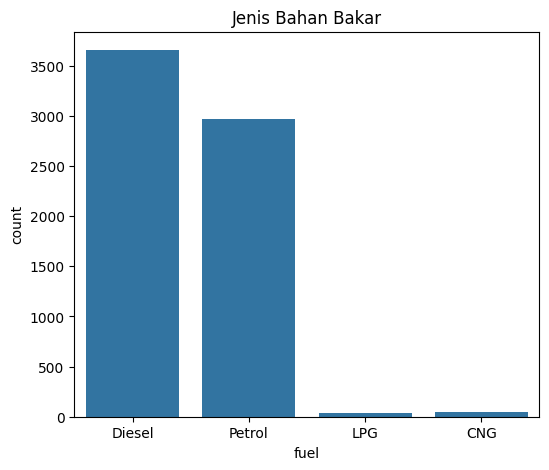

In [8]:
# ============================================================
# Jenis Bahan Bakar
# ============================================================

plt.figure(figsize=(6,5))

sns.countplot(data=df, x='fuel')

plt.title("Jenis Bahan Bakar")

plt.show()

In [9]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object
mileage(km/ltr/kg),float64
engine,float64


# CELL 6

Pada tahap preprocessing dilakukan pembersihan data pada kolom max_power dengan menghilangkan satuan "bhp" sehingga dapat dikonversi menjadi numerik. Selanjutnya dilakukan proses encoding terhadap seluruh variabel kategorikal menggunakan LabelEncoder agar dapat diproses oleh algoritma machine learning.

In [10]:
# ============================================================
# CELL 6 : Data Preprocessing
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# -----------------------------
# Membersihkan kolom mileage
# -----------------------------
df["mileage(km/ltr/kg)"] = (
    df["mileage(km/ltr/kg)"]
    .astype(str)
    .str.replace(" kmpl", "", regex=False)
    .str.replace(" km/kg", "", regex=False)
    .str.strip()
)

df["mileage(km/ltr/kg)"] = pd.to_numeric(
    df["mileage(km/ltr/kg)"],
    errors="coerce"
)

# -----------------------------
# Membersihkan kolom engine
# -----------------------------
df["engine"] = (
    df["engine"]
    .astype(str)
    .str.replace(" CC", "", regex=False)
    .str.strip()
)

df["engine"] = pd.to_numeric(
    df["engine"],
    errors="coerce"
)

# -----------------------------
# Membersihkan kolom max_power
# -----------------------------
df["max_power"] = (
    df["max_power"]
    .astype(str)
    .str.replace(" bhp", "", regex=False)
    .str.strip()
)

# Ganti string kosong menjadi NaN
df["max_power"] = df["max_power"].replace("", np.nan)

# Ubah ke numerik
df["max_power"] = pd.to_numeric(
    df["max_power"],
    errors="coerce"
)

# -----------------------------
# Membersihkan seats
# -----------------------------
df["seats"] = pd.to_numeric(
    df["seats"],
    errors="coerce"
)

# -----------------------------
# Hapus semua data yang masih kosong
# -----------------------------
df.dropna(inplace=True)

# -----------------------------
# Encoding
# -----------------------------
categorical_columns = [
    "name",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("\nDataset setelah preprocessing")
print(df.head())

print("\nTipe Data")
print(df.dtypes)

DATA PREPROCESSING

Dataset setelah preprocessing
   name  year  selling_price  km_driven  fuel  seller_type  transmission  \
0  1249  2014         450000     145500     1            1             1   
1  1546  2014         370000     120000     1            1             1   
2   375  2006         158000     140000     3            1             1   
3   743  2010         225000     127000     1            1             1   
4  1290  2007         130000     120000     3            1             1   

   owner  mileage(km/ltr/kg)  engine  max_power  seats  
0      0               23.40  1248.0      74.00    5.0  
1      2               21.14  1498.0     103.52    5.0  
2      4               17.70  1497.0      78.00    5.0  
3      0               23.00  1396.0      90.00    5.0  
4      0               16.10  1298.0      88.20    5.0  

Tipe Data
name                    int64
year                    int64
selling_price           int64
km_driven               int64
fuel                

In [11]:
print(df[df["max_power"].astype(str).str.contains(r'^\s*$', regex=True, na=False)])

Empty DataFrame
Columns: [name, year, selling_price, km_driven, fuel, seller_type, transmission, owner, mileage(km/ltr/kg), engine, max_power, seats]
Index: []


# CELL 7
Tahap ini bertujuan untuk memisahkan variabel independen (fitur) dan variabel dependen (target). Variabel selling_price digunakan sebagai target prediksi, sedangkan seluruh kolom lainnya digunakan sebagai fitur masukan model

In [12]:
# ============================================================
# CELL 7 : Pemisahan Fitur dan Target
# ============================================================

X = df.drop('selling_price', axis=1)

y = df['selling_price']

print("Jumlah Feature :", X.shape)

print("Jumlah Target :", y.shape)

Jumlah Feature : (6717, 11)
Jumlah Target : (6717,)


In [13]:
# ============================================================
# CELL 8 : Split Dataset
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Training :", X_train.shape)

print("Data Testing :", X_test.shape)

Data Training : (5373, 11)
Data Testing : (1344, 11)


In [14]:

# ============================================================
# CELL 9 : Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
# ============================================================
# CELL 10 : Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("="*60)
print("LINEAR REGRESSION")
print("="*60)

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score :", r2_score(y_test, y_pred_lr))

LINEAR REGRESSION
MAE : 168619.88164310437
MSE : 74712032914.12492
RMSE : 273335.0195531574
R2 Score : 0.6595188939128173


In [16]:
# ============================================================
# CELL 11 : Decision Tree Regression
# ============================================================

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("="*60)
print("DECISION TREE REGRESSION")
print("="*60)

print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

DECISION TREE REGRESSION
MAE : 98469.3583829365
MSE : 44929782290.81134
RMSE : 211966.4650146606
R2 Score : 0.7952439336215734


In [17]:
# ============================================================
# CELL 12 : Random Forest Regression
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("="*60)
print("RANDOM FOREST REGRESSION")
print("="*60)

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score :", r2_score(y_test, y_pred_rf))

RANDOM FOREST REGRESSION
MAE : 72933.82638961522
MSE : 16571969438.72862
RMSE : 128732.16163309237
R2 Score : 0.9244774601297918


In [18]:
# ============================================================
# CELL 13 : Perbandingan Model
# ============================================================

hasil = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

hasil

,Model,MAE,RMSE,R2 Score
0,Linear Regression,168619.881643,273335.019553,0.659519
1,Decision Tree,98469.358383,211966.465015,0.795244
2,Random Forest,72933.826390,128732.161633,0.924477


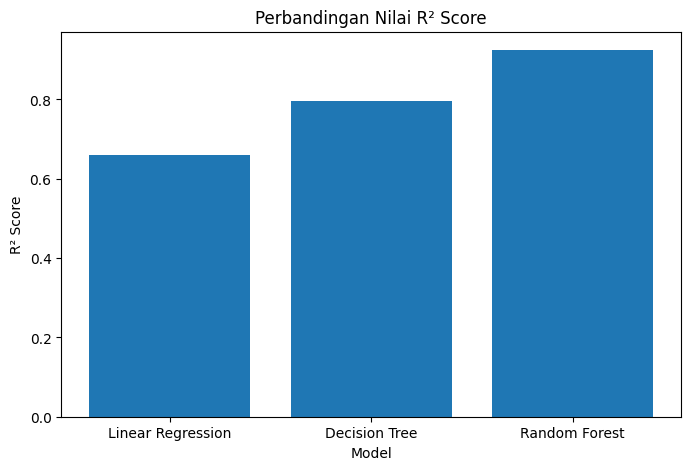

In [19]:
# ============================================================
# CELL 14 : Visualisasi Perbandingan Model
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(hasil['Model'], hasil['R2 Score'])

plt.title("Perbandingan Nilai R² Score")

plt.xlabel("Model")

plt.ylabel("R² Score")

plt.show()

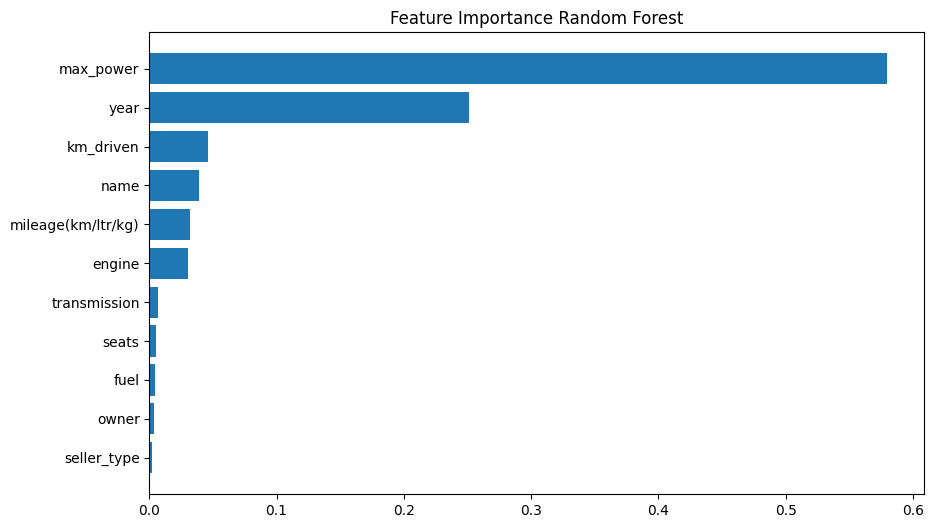

In [20]:
# ============================================================
# CELL 15 : Feature Importance
# ============================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance Random Forest")

plt.show()

In [ ]:
# ============================================================
# CELL 16 : Save Model
# ============================================================

import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Random Forest berhasil disimpan.")

Model Random Forest berhasil disimpan.


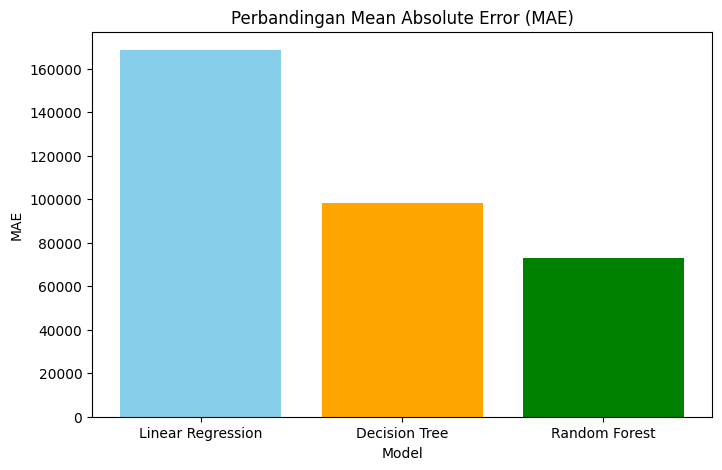

In [21]:
# ============================================================
# CELL 17 : Visualisasi MAE
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(hasil['Model'], hasil['MAE'], color=['skyblue','orange','green'])

plt.title("Perbandingan Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()

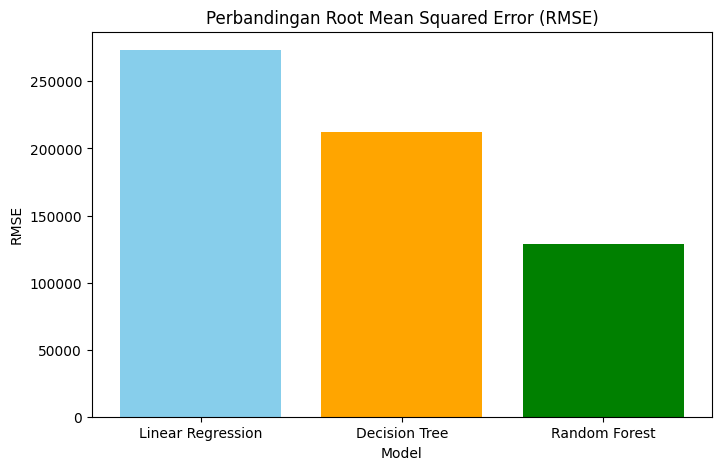

In [22]:
# ============================================================
# CELL 18 : Visualisasi RMSE
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(hasil['Model'], hasil['RMSE'], color=['skyblue','orange','green'])

plt.title("Perbandingan Root Mean Squared Error (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

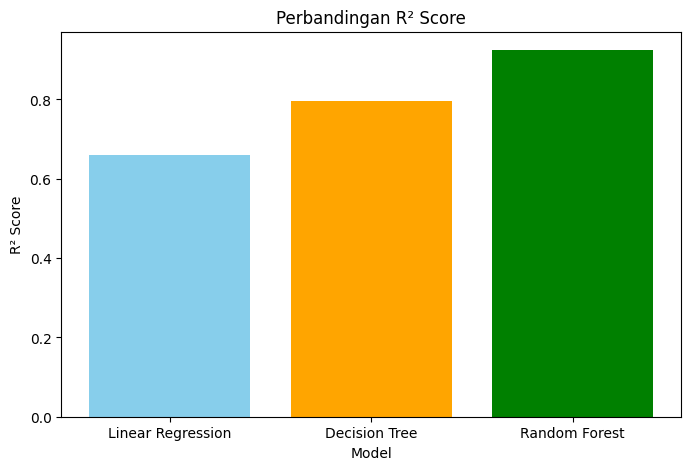

In [23]:
# ============================================================
# CELL 19 : Visualisasi R² Score
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(hasil['Model'], hasil['R2 Score'], color=['skyblue','orange','green'])

plt.title("Perbandingan R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.show()

In [24]:
# ============================================================
# CELL 20 : Feature Importance
# ============================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
9,max_power,0.580052
1,year,0.251013
2,km_driven,0.045776
0,name,0.038789
7,mileage(km/ltr/kg),0.032071
8,engine,0.030429
5,transmission,0.006496
10,seats,0.005534
3,fuel,0.004692
6,owner,0.003424


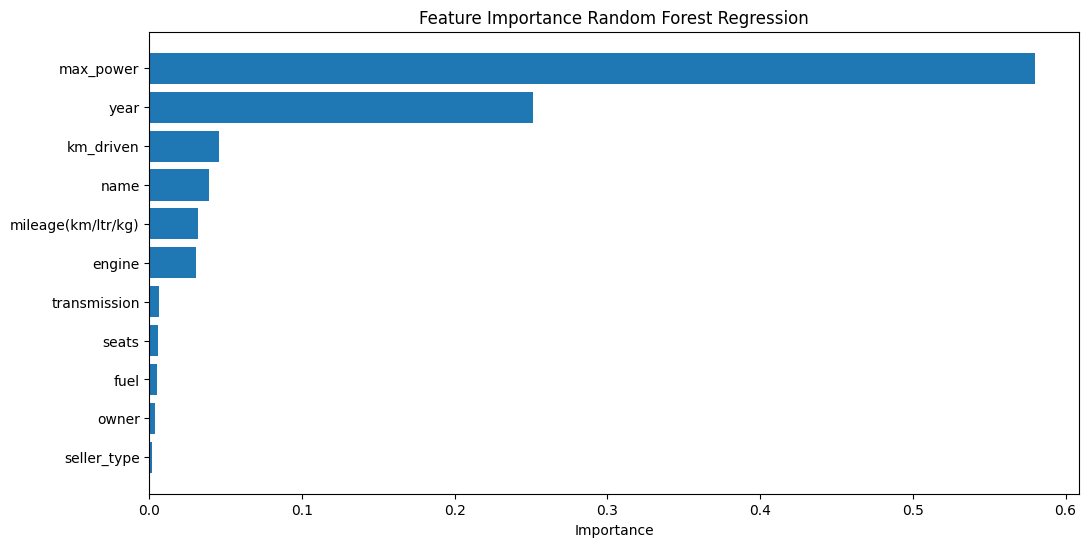

In [25]:
# ============================================================
# CELL 21 : Visualisasi Feature Importance
# ============================================================

plt.figure(figsize=(12,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance Random Forest Regression")

plt.xlabel("Importance")

plt.show()

In [26]:
# ============================================================
# CELL 22 : Prediksi Data Baru
# ============================================================

data_baru = [[
    120,
    2020,
    35000,
    1,
    0,
    1,
    0,
    20,
    1200,
    82,
    5
]]

prediksi = rf_model.predict(data_baru)

print("="*60)
print("HASIL PREDIKSI")
print("="*60)

print(f"Estimasi Harga Mobil : Rp {prediksi[0]:,.0f}")

HASIL PREDIKSI
Estimasi Harga Mobil : Rp 481,764


In [27]:
# ============================================================
# CELL 16 : Save Model
# ============================================================

import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("Model Random Forest berhasil disimpan.")
print("Encoder berhasil disimpan.")

Model Random Forest berhasil disimpan.
Encoder berhasil disimpan.


In [ ]:
# ============================================================
# CELL 24 : Save Scaler
# ============================================================

joblib.dump(scaler, "scaler.pkl")

print("Scaler berhasil disimpan.")

Scaler berhasil disimpan.


In [ ]:
# ============================================================
# CELL 25 : Download Model
# ============================================================

from google.colab import files

files.download("model.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import joblib

encoders = joblib.load("encoders.pkl")

print(encoders["fuel"].classes_)
print(encoders["seller_type"].classes_)
print(encoders["transmission"].classes_)
print(encoders["owner"].classes_)
print(encoders["name"].classes_[:10])

['CNG' 'Diesel' 'LPG' 'Petrol']
['Dealer' 'Individual' 'Trustmark Dealer']
['Automatic' 'Manual']
['First Owner' 'Fourth & Above Owner' 'Second Owner' 'Test Drive Car'
 'Third Owner']
['Ambassador CLASSIC 1500 DSL AC' 'Ambassador Classic 2000 DSZ AC PS'
 'Ambassador Grand 1500 DSZ BSIII' 'Ambassador Grand 2000 DSZ PW CL'
 'Ashok Leyland Stile LE' 'Audi A3 35 TDI Premium Plus'
 'Audi A3 40 TFSI Premium' 'Audi A4 1.8 TFSI' 'Audi A4 2.0 TDI'
 'Audi A4 2.0 TDI 177 Bhp Premium Plus']


In [29]:
print(type(encoders))
print(encoders)

<class 'dict'>
{'name': LabelEncoder(), 'fuel': LabelEncoder(), 'seller_type': LabelEncoder(), 'transmission': LabelEncoder(), 'owner': LabelEncoder()}


In [ ]:
import joblib

enc = joblib.load("encoders.pkl")
mdl = joblib.load("model.pkl")

print(type(enc))
print(type(mdl))

<class 'dict'>
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [30]:
print(type(joblib.load("model.pkl")))
print(type(joblib.load("encoders.pkl")))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
<class 'dict'>


In [31]:
print(df["selling_price"].describe())

count    6.717000e+03
mean     5.263860e+05
std      5.235504e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.200000e+05
75%      6.500000e+05
max      1.000000e+07
Name: selling_price, dtype: float64


In [32]:
print(df["selling_price"].head())

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64


In [33]:
print(X.columns)

Index(['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats'],
      dtype='object')


In [ ]:
print(r2_score(y_test, y_pred_rf))

0.9244774601297918


In [ ]:
sample = X.iloc[[0]]

print(sample)

print("Prediksi :", rf_model.predict(sample)[0])

print("Harga Asli :", y.iloc[0])

   name  year  km_driven  fuel  seller_type  transmission  owner  \
0  1249  2014     145500     1            1             1      0   

   mileage(km/ltr/kg)  engine  max_power  seats  
0                23.4  1248.0       74.0    5.0  
Prediksi : 468214.89
Harga Asli : 450000


In [ ]:
print(df.iloc[0])

name                    1249.0
year                    2014.0
selling_price         450000.0
km_driven             145500.0
fuel                       1.0
seller_type                1.0
transmission               1.0
owner                      0.0
mileage(km/ltr/kg)        23.4
engine                  1248.0
max_power                 74.0
seats                      5.0
Name: 0, dtype: float64


In [ ]:
mobil = "Maruti Swift Dzire ZDI"

kode = encoders["name"].transform([mobil])[0]

row = df[df["name"] == kode]

print(row.head())

      name  year  selling_price  km_driven  fuel  seller_type  transmission  \
22    1259  2015         525000      40000     1            1             1   
64    1259  2015         630000     147000     1            1             1   
869   1259  2017         695000      50000     1            1             1   
2442  1259  2016         550000      55000     1            1             1   
2869  1259  2017         700000      70000     1            1             1   

      owner  mileage(km/ltr/kg)  engine  max_power  seats  
22        0               26.59  1248.0      74.00    5.0  
64        2               26.59  1248.0      74.00    5.0  
869       0               26.59  1248.0      74.00    5.0  
2442      0               26.59  1248.0      74.00    5.0  
2869      0               28.40  1248.0      74.02    5.0  
